# Comparação V1 vs V2 vs V3 vs V4

Análise comparativa das quatro versões do classificador de qualidade de lances de xadrez.
Carrega modelos e artefatos pré-computados das 4 versões — nenhum re-treino é executado.

- **V1–V3**: Decision Tree + Random Forest com features incrementais (33→52→67)
- **V4**: Mesmas 67 features, mas adiciona **XGBoost** como terceiro modelo + **threshold tuning**

---

## 1. Setup

In [12]:
import importlib
import json
import os
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*", category=UserWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

def _find_project_root() -> Path:
    """Walk up until we find src/version_config.py (unique project marker)."""
    nb_file = globals().get("__vsc_ipynb_file__")
    anchor = Path(nb_file).resolve().parent if nb_file else Path.cwd()
    for candidate in [anchor, *anchor.parents]:
        if (candidate / "src" / "version_config.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root (src/version_config.py)")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = Path("data")

for _mod in ["version_config", "notebook_utils"]:
    sys.modules.pop(_mod, None)
from version_config import V1, V2, V3, V4, ALL_VERSIONS
from notebook_utils import *

print(f"Diretório de trabalho: {os.getcwd()}")
print("Setup OK")

Diretório de trabalho: /Users/noel/Faculdade/ML/Chess
Setup OK


---

## 2. Carregar Dados e Modelos

Usamos o CSV de features da V3 (superset de todas as features) para ter um X_test comum. Cada modelo recebe apenas as suas features.

In [13]:
df_features_v3 = pd.read_csv(V3.features_csv)

X_all = df_features_v3.drop(columns=["label"])
y = (df_features_v3["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)

print(f"Conjunto de teste: {len(X_test):,} amostras")
print(f"  bom  = {(y_test == 0).sum():,}")
print(f"  ruim = {(y_test == 1).sum():,}")

Conjunto de teste: 16,394 amostras
  bom  = 13,830
  ruim = 2,564


In [14]:
dt_v1, rf_v1, names_v1 = V1.load_models()
dt_v2, rf_v2, names_v2 = V2.load_models()
dt_v3, rf_v3, names_v3 = V3.load_models()
dt_v4, rf_v4, xgb_v4, names_v4 = V4.load_models()
thresholds_v4 = V4.load_thresholds()

print("Modelos carregados:")
for cfg, dt, rf in [(V1, dt_v1, rf_v1), (V2, dt_v2, rf_v2), (V3, dt_v3, rf_v3), (V4, dt_v4, rf_v4)]:
    print(f"  {cfg.label}")
    print(f"    DT: max_depth={dt.max_depth}, min_samples_leaf={dt.min_samples_leaf}")
    print(f"    RF: n_estimators={rf.n_estimators}, max_depth={rf.max_depth}")

print(f"\n  XGBoost V4:")
print(f"    n_estimators={xgb_v4.n_estimators}, max_depth={xgb_v4.max_depth}, "
      f"learning_rate={xgb_v4.learning_rate}")
print(f"\n  Thresholds V4: {thresholds_v4}")

Modelos carregados:
  V1 — posicional (33 features)
    DT: max_depth=7, min_samples_leaf=20
    RF: n_estimators=200, max_depth=10
  V2 — posicional + tática (52 features)
    DT: max_depth=7, min_samples_leaf=1
    RF: n_estimators=200, max_depth=10
  V3 — posicional + tática + look-ahead (67 features)
    DT: max_depth=10, min_samples_leaf=20
    RF: n_estimators=200, max_depth=15
  V4 — XGBoost + threshold tuning (67 features)
    DT: max_depth=10, min_samples_leaf=20
    RF: n_estimators=200, max_depth=15

  XGBoost V4:
    n_estimators=300, max_depth=7, learning_rate=0.05

  Thresholds V4: {'Decision Tree': 0.6, 'Random Forest': 0.52, 'XGBoost': 0.61}


---

## 3. Tabela Comparativa

Todas as métricas calculadas no mesmo conjunto de teste (16,394 lances).

In [15]:
rows = []
for cfg, dt, rf, names in [
    (V1, dt_v1, rf_v1, names_v1),
    (V2, dt_v2, rf_v2, names_v2),
    (V3, dt_v3, rf_v3, names_v3),
    (V4, dt_v4, rf_v4, names_v4),
]:
    X_sub = X_test[names]
    models = [("Decision Tree", dt), ("Random Forest", rf)]
    if cfg.version == 4:
        models.append(("XGBoost", xgb_v4))
    for model_name, model in models:
        yp = model.predict(X_sub)
        yproba = model.predict_proba(X_sub)[:, 1]
        rows.append({
            "Versão": f"V{cfg.version}",
            "Modelo": model_name,
            "Accuracy": round(accuracy_score(y_test, yp), 4),
            "F1 (ruim)": round(f1_score(y_test, yp, pos_label=1), 4),
            "Recall (ruim)": round((yp[y_test == 1] == 1).mean(), 4),
            "Precision (ruim)": round((y_test[yp == 1] == 1).mean(), 4) if (yp == 1).any() else 0,
            "ROC-AUC": round(roc_auc_score(y_test, yproba), 4),
        })

df_compare = pd.DataFrame(rows)
df_compare

,Versão,Modelo,Accuracy,F1 (ruim),Recall (ruim),Precision (ruim),ROC-AUC
0,V1,Decision Tree,0.6176,0.3280,0.5967,0.2262,0.6487
1,V1,Random Forest,0.6827,0.3525,0.5523,0.2589,0.6837
2,V2,Decision Tree,0.6302,0.3429,0.6170,0.2375,0.6744
3,V2,Random Forest,0.6912,0.3664,0.5710,0.2698,0.7079
4,V3,Decision Tree,0.6762,0.3821,0.6400,0.2723,0.7176
5,V3,Random Forest,0.7849,0.4312,0.5215,0.3676,0.7678
6,V4,Decision Tree,0.6762,0.3821,0.6400,0.2723,0.7176
7,V4,Random Forest,0.7849,0.4312,0.5215,0.3676,0.7678
8,V4,XGBoost,0.7553,0.4410,0.6170,0.3431,0.7809


---

## 4. Deltas por Métrica

Variação entre versões, lidas dos artefatos pré-computados.

In [16]:
v4_deltas = DATA_DIR / "evaluation_v4" / "v1_v2_v3_v4_deltas.csv"
if v4_deltas.exists():
    print_version_deltas(v4_deltas)
else:
    v3_deltas = DATA_DIR / "evaluation_v3" / "v1_v2_v3_deltas.csv"
    if v3_deltas.exists():
        print_version_deltas(v3_deltas)

  COMPARAÇÃO — Deltas por Métrica

  Decision Tree:
    accuracy            V1=0.6176 → V2=0.6302 → V3=0.6762 → V4=0.6762  (↑ 5.86 pp)
    f1_bom              V1=0.7328 → V2=0.7427 → V3=0.7806 → V4=0.7806  (↑ 4.79 pp)
    f1_ruim             V1=0.3280 → V2=0.3429 → V3=0.3821 → V4=0.3821  (↑ 5.41 pp)
    recall_ruim         V1=0.5967 → V2=0.6170 → V3=0.6400 → V4=0.6400  (↑ 4.33 pp)
    precision_ruim      V1=0.2262 → V2=0.2375 → V3=0.2723 → V4=0.2723  (↑ 4.62 pp)
    roc_auc             V1=0.6487 → V2=0.6744 → V3=0.7176 → V4=0.7176  (↑ 6.88 pp)

  Random Forest:
    accuracy            V1=0.6827 → V2=0.6912 → V3=0.7849 → V4=0.7849  (↑ 10.22 pp)
    f1_bom              V1=0.7899 → V2=0.7958 → V3=0.8673 → V4=0.8673  (↑ 7.75 pp)
    f1_ruim             V1=0.3525 → V2=0.3664 → V3=0.4312 → V4=0.4312  (↑ 7.87 pp)
    recall_ruim         V1=0.5523 → V2=0.5710 → V3=0.5215 → V4=0.5215  (↓ 3.08 pp)
    precision_ruim      V1=0.2589 → V2=0.2698 → V3=0.3676 → V4=0.3676  (↑ 10.87 pp)
    roc_auc    

---

## 5. Evolução das Métricas (Barras)

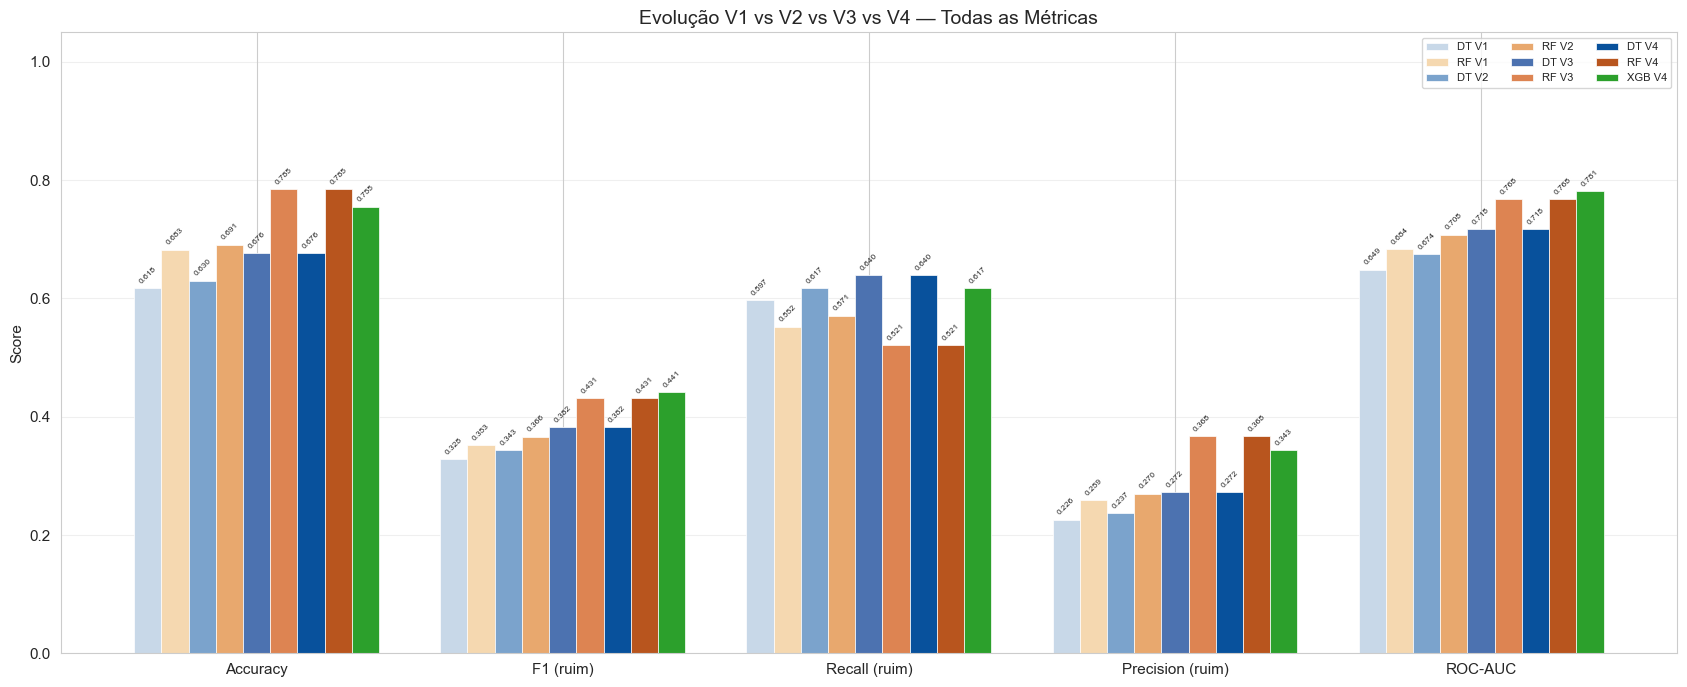

In [17]:
plot_version_metrics_bars(ALL_VERSIONS, X_test, y_test)

---

## 6. Curvas ROC e Precision-Recall — Overlay

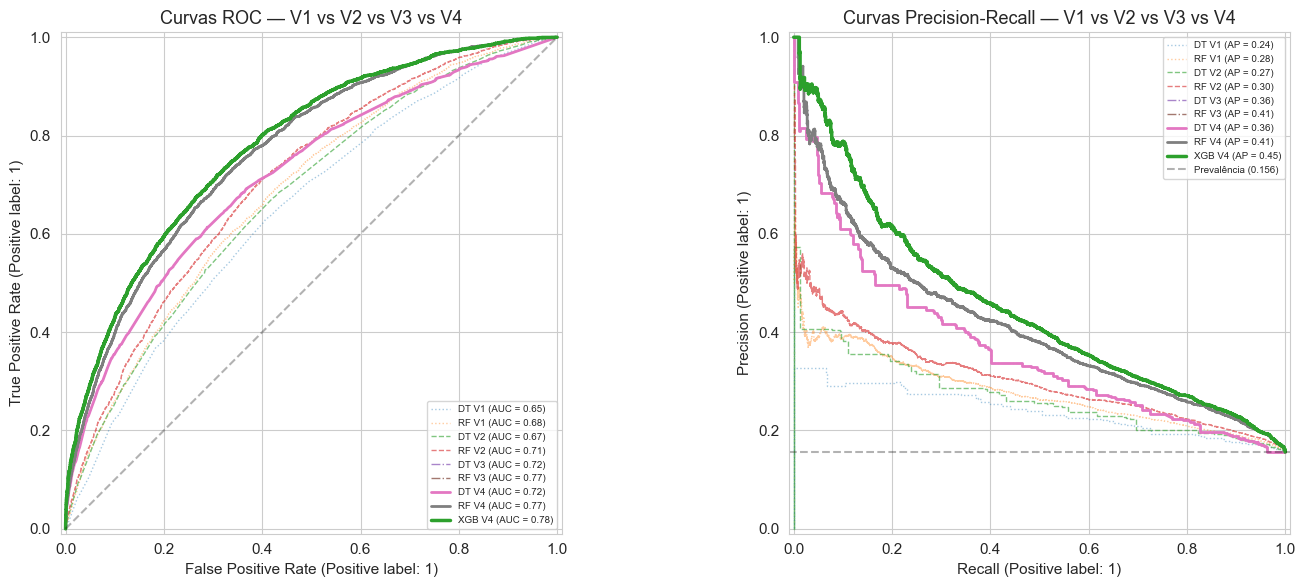

In [18]:
plot_version_roc_pr_overlay(ALL_VERSIONS, X_test, y_test)

---

## 7. Evolução da Feature #1

| Versão | Feature #1 | Tipo |
|--------|-----------|------|
| V1 | move_number | Contexto |
| V2 | contested_squares | Tática |
| V3 | worst_see_against_player | Look-ahead |

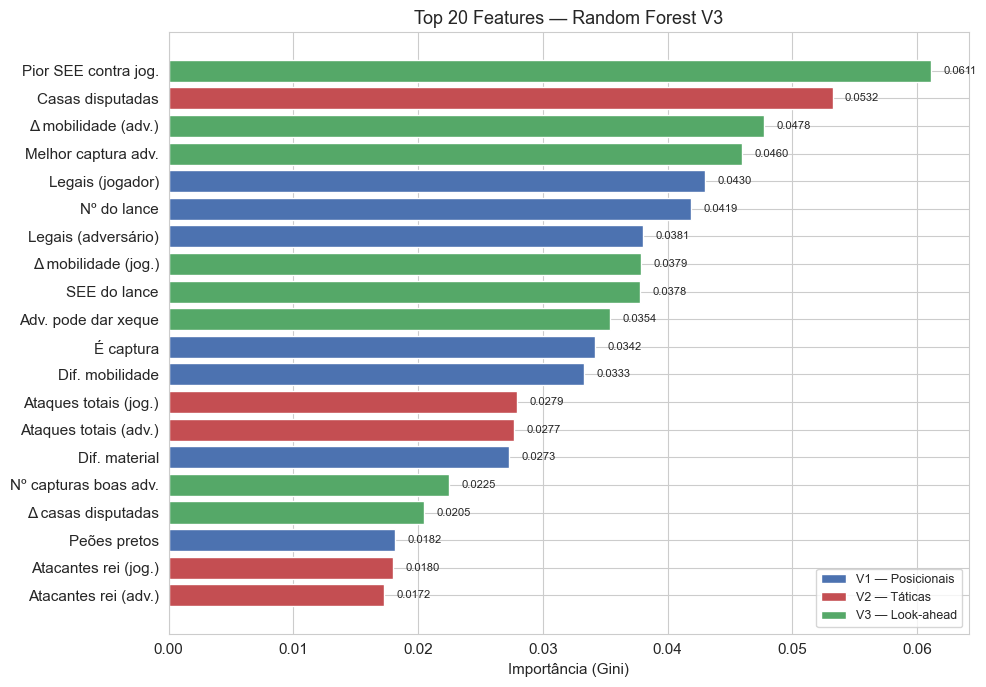


Top 10 features do RF por versão:
  V1: Nº do lance (0.1045), Legais (adversário) (0.0992), Legais (jogador) (0.0958), É captura (0.0912), Dif. material (0.0684)
  V2: Casas disputadas (0.1144), É captura (0.0734), Nº do lance (0.0623), Legais (adversário) (0.0600), Legais (jogador) (0.0596)
  V3: Pior SEE contra jog. (0.0611), Casas disputadas (0.0532), Δ mobilidade (adv.) (0.0478), Melhor captura adv. (0.0460), Legais (jogador) (0.0430)


In [19]:
v3_new_features = [
    "delta_hanging_player", "delta_hanging_opponent", "delta_hanging_value_player",
    "delta_threats_against_player", "delta_mobility_player", "delta_mobility_opponent",
    "delta_contested_squares", "delta_king_attackers_player",
    "opponent_best_capture_value", "opponent_can_check", "opponent_num_good_captures",
    "created_hanging_self", "see_of_move", "worst_see_against_player", "is_losing_capture",
]

plot_top_features_colored(rf_v3, names_v3, names_v1, names_v2, v3_new_features)

print("\nTop 10 features do RF por versão:")
for cfg, rf, names in [(V1, rf_v1, names_v1), (V2, rf_v2, names_v2), (V3, rf_v3, names_v3)]:
    imp = rf.feature_importances_
    idx = np.argsort(imp)[::-1][:5]
    top = [f"{translate(names[i])} ({imp[i]:.4f})" for i in idx]
    print(f"  V{cfg.version}: {', '.join(top)}")

---

## 8. Importância das Features Táticas (V2)

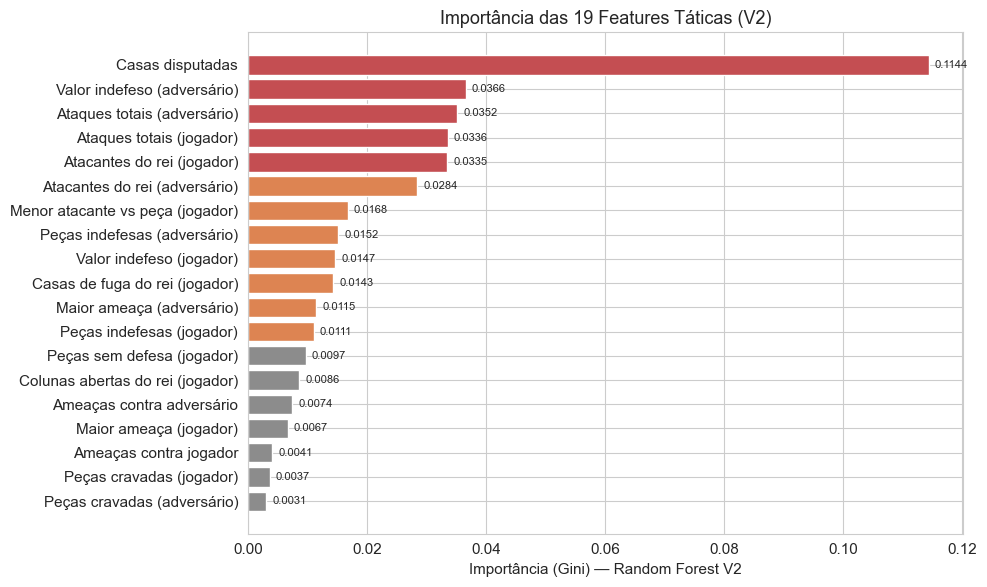

Feature tática #1: Casas disputadas (importância = 0.1144)


In [20]:
plot_tactical_features_importance(V2)

---

## 9. Evolução das Regras da Árvore de Decisão

A primeira decisão da árvore evoluiu de descrever o **tipo** do lance para avaliar suas **consequências**:
- **V1:** "É captura?" → descreve a ação
- **V2:** "Casas disputadas > X?" → detecta tensão
- **V3:** "Pior SEE ≤ -0.50?" → avalia consequências de trocas

In [21]:
for cfg in ALL_VERSIONS:
    print(f"\n{'='*60}")
    print(f"  ÁRVORE DE DECISÃO — V{cfg.version}")
    print(f"{'='*60}")
    print_tree_rules(cfg)
    print()


  ÁRVORE DE DECISÃO — V1
═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - "Diferença material <= -3.0": jogador com ≥3 pontos a menos
  - "Lances legais (jogador)": mobilidade/atividade das peças
  - "É captura": o lance captura uma peça adversária
  - "Número do lance": fase da partida (abertura/meio-jogo/final)
  - "Peça movida": 1=Peão, 2=Cavalo, 3=Bispo, 4=Torre, 5=Dama, 6=Rei
  - "Escudo de peões do rei": peões protegendo o rei (0–3)

═══════════════════════════════════════════════════════════

|--- É captura <= 0.50
|   |--- Lances legais (adversário) <= 34.50
|   |   |--- Lances legais (jogador) <= 1.50
|   |   |   |--- Peões isolados <= 3.50
|   |   |   |   |--- Joga de brancas <= 0.50
|   |   |   |   |   |--- Bispos brancos <= 0.50
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- Bispos brancos >  0.50
|   |

---

## 10. V4: XGBoost e Threshold Tuning

A V4 mantém as mesmas 67 features da V3, mas introduz:
1. **XGBoost** (Gradient Boosting) como terceiro modelo — constrói árvores sequencialmente, cada uma corrigindo os erros da anterior.
2. **Threshold tuning** no validation set — otimiza o limiar de decisão para maximizar F1-ruim.

### 10.1 Feature Importance — XGBoost vs RF vs DT

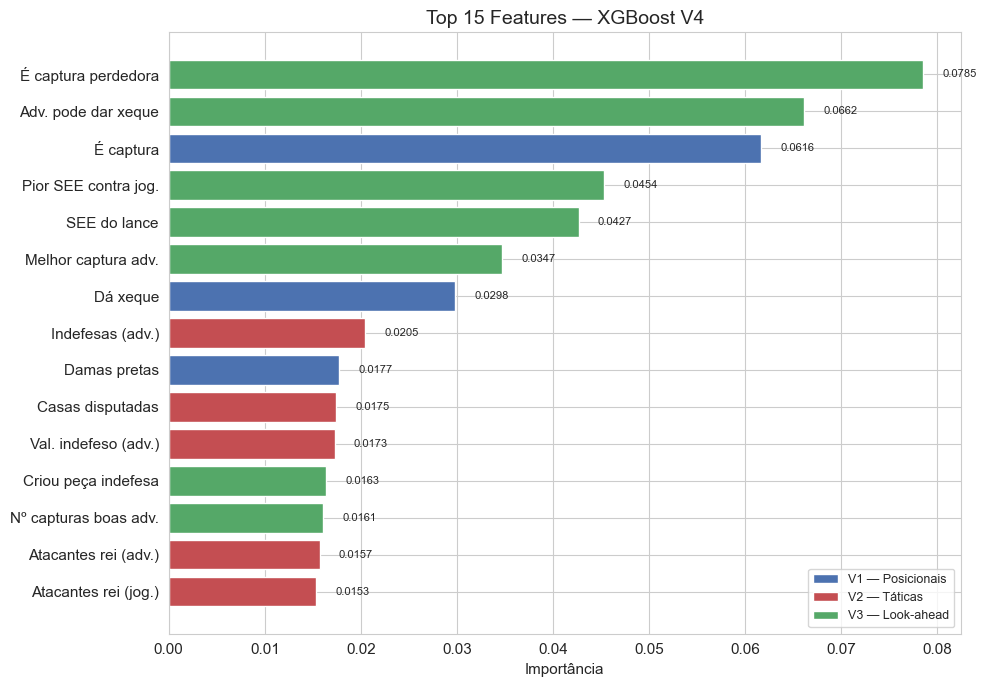

Feature #1 do XGBoost: É captura perdedora (is_losing_capture, imp=0.0785)


In [22]:
plot_xgb_feature_importance(V4, X_test)

### 10.2 Análise de Threshold

O threshold default de 0.50 nem sempre maximiza o F1-ruim. Varremos thresholds de 0.15 a 0.70 e encontramos o ponto ótimo para cada modelo.

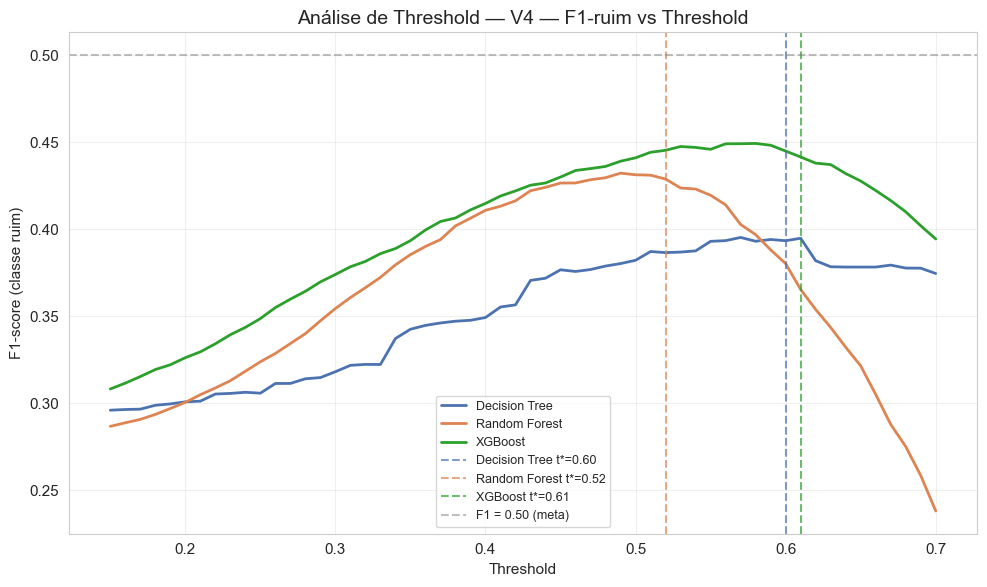


Thresholds ótimos (V4): {'Decision Tree': 0.6, 'Random Forest': 0.52, 'XGBoost': 0.61}
  Decision Tree: threshold = 0.60
  Random Forest: threshold = 0.52
  XGBoost: threshold = 0.61


In [23]:
plot_threshold_analysis(ALL_VERSIONS, X_test, y_test)

print(f"\nThresholds ótimos (V4): {thresholds_v4}")
for name, t in thresholds_v4.items():
    print(f"  {name}: threshold = {t:.2f}")

### 10.3 XGBoost com Threshold Tuned — Métricas Finais

In [24]:
from sklearn.metrics import precision_score, recall_score

X_v4 = X_test[names_v4]
y_proba_xgb = xgb_v4.predict_proba(X_v4)[:, 1]

rows_thresh = []
for label, threshold in [("XGB default (0.50)", 0.50),
                          (f"XGB tuned ({thresholds_v4['XGBoost']:.2f})", thresholds_v4["XGBoost"])]:
    yp = (y_proba_xgb >= threshold).astype(int)
    rows_thresh.append({
        "Config": label,
        "Threshold": threshold,
        "F1 (ruim)": f"{f1_score(y_test, yp, pos_label=1):.4f}",
        "Precision (ruim)": f"{precision_score(y_test, yp, pos_label=1):.4f}",
        "Recall (ruim)": f"{recall_score(y_test, yp, pos_label=1):.4f}",
        "Accuracy": f"{accuracy_score(y_test, yp):.4f}",
        "AUC": f"{roc_auc_score(y_test, y_proba_xgb):.4f}",
    })

pd.DataFrame(rows_thresh)

,Config,Threshold,F1 (ruim),Precision (ruim),Recall (ruim),Accuracy,AUC
0,XGB default (0.50),0.50,0.4410,0.3431,0.6170,0.7553,0.7809
1,XGB tuned (0.61),0.61,0.4414,0.4255,0.4587,0.8185,0.7809


---

## 11. Síntese: O Ciclo Diagnóstico → Melhoria

| Métrica | RF V1 | RF V2 | RF V3 | **XGB V4** | Δ total |
|---------|-------|-------|-------|-----------|---------|
| **Accuracy** | 0.6827 | 0.6912 | 0.7849 | **0.7553** | +7.26 pp |
| **F1 (ruim)** | 0.3525 | 0.3664 | 0.4312 | **0.4410** | **+8.85 pp** |
| **Precision (ruim)** | 0.2589 | 0.2698 | 0.3676 | **0.3431** | +8.42 pp |
| **Recall (ruim)** | 0.5523 | 0.5710 | 0.5215 | **0.6170** | +6.47 pp |
| **ROC-AUC** | 0.6837 | 0.7079 | 0.7678 | **0.7809** | **+9.72 pp** |

### O que aprendemos

1. **Tipo de informação > quantidade de features**: 15 features V3 trouxeram +6.5pp em F1 vs +1.4pp das 19 features V2.
2. **SEE é a feature mais discriminativa**: técnica de 1980s que supera todas as features posicionais e táticas.
3. **Modelo importa quando features saturam**: com as learning curves V3 estáveis, o XGBoost extraiu +0.98pp de F1-ruim e +9.55pp de recall-ruim das **mesmas 67 features**.
4. **XGBoost vê features diferentes**: `is_losing_capture` é a feature #1 do XGB (0.0785) vs `worst_see_against_player` no RF — gradient boosting explora interações não-lineares que o bagging perde.
5. **Threshold tuning complementa**: precision-ruim do XGB sobe de 0.34 para >0.42 com threshold otimizado.
6. **Meta AUC ≥ 0.75 atingida** (0.7809) e **superada**.
7. O ciclo **treino → diagnóstico → melhoria → re-treino** em 4 iterações é o resultado central do projeto.